In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.coordinates import Angle
from astropy.time import Time
import h5py

import lsst.afw.display as afwDisplay
from lsst.afw.image import ExposureF
from lsst.afw.image import MultibandExposure

from lsst.afw.fits import MemFileManager

from lsst.rsp.utils import get_pyvo_auth
from lsst.rsp.service import get_siav2_service
from lsst.rsp import get_tap_service
import lsst.geom as geom
from lsst.daf.butler import Butler

from pyvo.dal.adhoc import DatalinkResults, SodaQuery
import pandas as pd

import lsst.scarlet.lite as sl
import lsst.meas.extensions.scarlet as mes
from lsst.afw.fits import makeLimitedFitsHeader


### Making metadata

This notebook demonstrates how to make DeepDISC metadata from the LSST deblender

It involves getting the scarlet models for detected objects and producing segmentation masks by thresholding the models

First, let's make some helper functions

In [7]:
from numpy.typing import DTypeLike
from lsst.scarlet.lite import Box, Blend, Observation


def minimal_data_to_blend(cls, model_psf: np.ndarray, dtype: DTypeLike) -> Blend:

    """Convert the storage data model into a scarlet lite blend

    Parameters
    ----------
    model_psf:
        PSF in model space (usually a nyquist sampled circular Gaussian).
    dtype:
        The data type of the model that is generated.

    Returns
    -------
    blend:
        A scarlet blend model extracted from persisted data.
    """
    model_box = Box(cls.shape, origin=cls.origin)
    observation = Observation.empty(
        bands=cls.bands,
        psfs=cls.psf,
        model_psf=model_psf,
        bbox=model_box,
        dtype=dtype,
    )
    return cls.to_blend(observation)


import lsst.scarlet as scarlet
scarlet.lite.io.ScarletBlendData.minimal_data_to_blend = minimal_data_to_blend

In [8]:
#Need this custom function to add WCS info to the multiband exposure, otherwise it is None
def MultiBandExposure_withWCS(butler,ordered_bands,dtype,dataId):

    """ Produce a MultiBandExposure from the butler, but save WCS info (not default behavior)

    Parameters
    ----------
    butler:
        LSST Butler
    ordered_bands:
        List of the ordered bands, corresponding to the first axis of the image array
    dtype:
        Dataset type to get form the butler, e.g., "deep_coadd"
    dataId:
        dataId containing tract/patch
    Returns
    -------
    mCoadd:
        A MultiBandExposure that has WCS information
    """

    coadds = []
    for b in ordered_bands:
        coadd = butler.get('deep_coadd', band=b,
                         tract=dataId['tract'], patch=dataId['patch'])
        coadds.append(coadd)
    mCoadd = MultibandExposure.fromExposures(ordered_bands, coadds)

    #Add WCS
    for band, exposure in zip(ordered_bands, coadds):
        mCoadd[band].setWcs(exposure.getWcs())
    return mCoadd



The `make_cutout` function will take an RA and DEC and produce a catalog of objects within a box centered around those coordinates.  

**Note**: There is no filter applied to the object table here.  You may want to make some cuts

In [9]:

def make_cutout_cat(butler,query,ra,dec,cutoutSideLength=64):

    
    """ Produce a catalog within a cutout region centered on an RA/DEC

    Parameters
    ----------
    butler:
        LSST Butler
    query:
        A query string.  This is fed into the butler to produce the dataset_refs for a given coordinate
    dtype:
        Dataset type to get form the butler, e.g., "deep_coadd"
    ra:
        coordinate RA
    dec:
        coordinate DEC
    cutoutSideLength:
        size of the (square) cutout
    Returns
    -------
    cutout_cat:
        The catalog of LSST-detected objects within the cutout
    cutout_bbox: 
        The bounding box of the cutout relative to the LSST coordinate system
    dataId:
        The dataId (tract,patch,skymap) of the cutout
    """


    dataset_refs = butler.query_datasets("deep_coadd", where=query)
    print('Found ', len(dataset_refs), ' dataset refs')

    col_list = ['objectId', 'parentObjectId', 'coord_ra','coord_dec']
    
    cutout_cats=[]
    cutout_bboxes=[]
    dataIds=[]

    for dataref in dataset_refs:
        
        dataId = dataref.dataId   
        tract = dataId['tract']
        patch = dataId['patch']

        objects = butler.get("object", dataId,
                            parameters={'columns': col_list})
        objects = objects.to_pandas()
        
        #ra = ras[ind]
        #dec = decs[ind]
        radec = geom.SpherePoint(ra, dec, geom.degrees)
        tractInfo = skymap[tract]
        
        cutoutSize = geom.ExtentI(cutoutSideLength, cutoutSideLength)
        center = tractInfo.getWcs().skyToPixel(radec)
        cutout_bbox = geom.BoxI(geom.Point2I((center.x - cutoutSideLength*0.5, center.y - cutoutSideLength*0.5)), cutoutSize)
        
        
        xys= [geom.PointI(tractInfo.getWcs().skyToPixel(geom.SpherePoint(ra,dec,geom.degrees))) for ra,dec in zip(objects.coord_ra.values,objects.coord_dec.values)]
        cp = np.array([cutout_bbox.contains(xy) for xy in xys])
        cutout_cat = objects.iloc[cp].copy()

        
        if len(cutout_cat)>0:
            print('Catalog produced with dataId ', dataId)
            cutout_cats.append(cutout_cat)
            cutout_bboxes.append(cutout_bbox)
            dataIds.append(dataId)
        else:
            print('No catalog produced with dataId ', dataId, ',trying next dataId')
            continue

    return cutout_cats,cutout_bboxes,dataIds


### Compute the segmasks based on the models and image noise

The mask is produced by re-creating the scarlet model. The model can be either the scarlet model or the 'flux conserved' model.  See the DP1 deblender tutorial for the difference between them.  Once we have the model, we can simply select all pixels above zero, or select pixels above a threshold.  The default in the code below is to threshold the scarlet model above 2x the image variance.

In [10]:
def get_segmask(modelData,mCoadd,cutout_bbox,parentId,objectId,mask_source,threshold=None):
    
    mCoadd_cutout = mCoadd[:,cutout_bbox]
    model_psf = modelData.psf
    if parentId not in modelData.blends.keys():
        print(f'Scarlet blend model is missing parent {parentId} for object {objectId}')
        return np.zeros((cutout_bbox.height,cutout_bbox.width))
    
    blend_data = modelData.blends[parentId]
    

    blend = blend_data.minimal_data_to_blend(model_psf[None, :, :], dtype=np.float32)

    #observed_bands = blend_data.bands
    #box = sl.Box(blend_data.shape, blend_data.origin)
    #blend_bbox = mes.utils.scarletBoxToBBox(box)

    observation = mes.utils.buildObservation(modelPsf=model_psf,
                                         psfCenter=cutout_bbox.getCenter(),
                                         mExposure=mCoadd_cutout,
                                         )

    blend = blend_data.to_blend(observation)

    #Grab the index of the object in the blend 
    source_ids = np.array([s.record_id for s in blend.sources])
    blend_source_ind = int(*np.where(source_ids==objectId))  #TODO: check if the objectId does indeed exist in the blend

    blend.conserve_flux()


    source = blend.sources[blend_source_ind]
    source_model = source.get_model()

    flux_model = source.flux_weighted_image
    flux_model = source.flux_weighted_image.project(bbox=blend.bbox)

    convolved_model = source_model.copy().project(bbox=blend.bbox)
    convolved_model = blend.observation.convolve(convolved_model,mode='real')

    
    #make the segmask 
    #either threshold the scarlet model or the flux conserved model above an SNR defined by the observation variance
    mask = np.zeros(flux_model.data.shape[1:])


    if mask_source not in ['scarlet_model','flux_conserved_model']:
        raise NotImplementedError('mask_source must be either scarlet_model or flux_conserved_model')
    
    if mask_source=='scarlet_model':
        if threshold is not None:
            for i in range(convolved_model.n_bands):
                mask+=convolved_model.data[i]>threshold*np.sqrt(observation.variance.data[i])
            mask = mask>0
        else:
            mask = np.max(convolved_model.data, axis=0) != 0
            
    elif mask_source=='flux_conserved_model': 
        if threshold is not None:
            for i in range(flux_model.n_bands):
                mask+=flux_model.data[i]>threshold*np.sqrt(observation.variance.data[i])
            mask = mask>0
        else:
            mask = np.max(flux_model.data, axis=0) != 0

    return mask.astype(int)


def get_bbox(mask):
    """
    Calculates the bounding box of a mask. Returns None if the mask is empty.
    """
    h= mask.shape[0]
    w = mask.shape[1]
    if not np.any(mask):
        print("No bbox because mask is empty!")
        return None
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    #keep inside cutout bounds
    return max(0,rmin-4), min(rmax+4,w), max(0,cmin-4), min(cmax+4,h)


In [11]:
import cv2
def annotate_dp1(imgid,cutout_cat,modelData,mCoadd,cutout_bbox,column_keys,mask_source='scarlet_model',threshold=2):

    
    record = {}

    custom_cols = {}
        
    record[f"filename"] = f'image_{imgid}'
    record["image_id"] = imgid
    record["height"] = cutout_bbox.height
    record["width"] = cutout_bbox.width
    objs = []

    # Generate segmentation masks for each source from the scarlet models 
    for i in range(len(cutout_cat)):
        parentId = cutout_cat['parentObjectId'].iloc[i].astype(np.int64)
        objectId = cutout_cat['objectId'].iloc[i].astype(np.int64)
        
        mask = get_segmask(modelData,mCoadd,cutout_bbox,parentId,objectId,mask_source=mask_source,threshold=threshold)        
        if np.all(mask==0):
            print(f'Failed to produce mask for source {objectId}')
            continue
        bbox = get_bbox(mask)
    
        y0,y1,x0,x1=bbox
        w = x1-x0
        h = y1-y0
        
        # https://github.com/facebookresearch/Detectron/issues/100
        contours, hierarchy = cv2.findContours(
            (mask).astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
        )
        segmentation = []
        for contour in contours:
            contour = contour.flatten()
            if len(contour) > 4:
            #    contour[::2] += x - w // 2
            #    contour[1::2] += y - h // 2
                segmentation.append(contour.tolist())
        # No valid countors
        if len(segmentation) == 0:
            print('No valid contours for mask of object ', i)
            continue

        # Add to dict
        obj = {
            "bbox": [x0, y0, w, h],
            "area": w * h,
            "bbox_mode": 1, # indicates X0,Y0,W,H box
            "segmentation": segmentation,
            "category_id": 0,
            #"redshift": redshifts[i],
            #"obj_id": obj_ids[i],
            #"mag_i": mag_is[i],
        }
    
        if column_keys is not None:
            for col in column_keys:
                obj[col] = cutout_cat[col].iloc[i]

        objs.append(obj)

    record["annotations"] = objs


    uband = mCoadd['u'][cutout_bbox]
    uband.setXY0(geom.PointI(0, 0))
    wcs = uband.getWcs()
    wcs_header = makeLimitedFitsHeader(wcs.getFitsMetadata()) 


    record['wcs'] = wcs_header

    return record

    

### Single example

Let's demonstrate how you can produce annotations for a single cutout.  Note that this is very inefficient for many small cutouts with random tract/patch ordering, as most of the computational bottleneck happens when we query the butler for the images and scarlet data products.  If we re-run this query for every cutout, it will take quite a long time.

To speed things up, we can run the process for a single patch at a time, meaning we can reuse the queried image and scarlet models.  This isn't implemented here, but you can check the prep_dp1_for_dd_scarlet.ipynb notebook for more efficient querying

First load in the LSST butler

In [12]:
butler = Butler("dp1", collections="LSSTComCam/DP1")
skymap = butler.get("skyMap", skymap="lsst_cells_v1")

We will also load in a set of RA/DEC coordinates to produce cutouts.

In [13]:
trainfile='/home/g4merz/DATA/dp1_matched_v4_train.hdf5'
with h5py.File(trainfile,'r') as f:
    #print(f.keys())
    objectIds = f['objectId'][:]
    ras = f['coord_ra'][:]
    decs = f['coord_dec'][:]


We get the tract and patch corresponding to the provided coordinates.
Then we get the catalog of objects within the cutout box centered on the coordinates

In [ ]:
ind=3
ra = ras[ind]
dec = decs[ind]
query = """band.name = '{}' AND patch.region OVERLAPS POINT({}, {})
        """.format('i', ra, dec)

#The data might be on a few different tract/patches due to overlap
cutout_cats,cutout_bboxes,dataIds = make_cutout_cat(butler,query,ra,dec)

#We grab the image and store it in a MultiBandExposure
#have to use custom function to save WCS info 
ordered_bands = ('u', 'g', 'r', 'i', 'z', 'y')


In [50]:
dataset_refs = butler.query_datasets("deep_coadd", where=query)
dataset_refs

[DatasetRef(DatasetType('deep_coadd', {band, skymap, tract, patch}, ExposureF), {band: 'i', skymap: 'lsst_cells_v1', tract: 5063, patch: 25}, run='LSSTComCam/runs/DRP/DP1/DM-51335', id=aa938fe3-38ee-4d60-9a28-4c7e4868bc46)]

In [14]:
def make_annotations(imgid,butler,cutout_cats,cutout_bboxes,dataIds):

    for i,(cutout_cat,cutout_bbox,dataId) in enumerate(zip(cutout_cats,cutout_bboxes,dataIds)): 
        print(f'Making annotations using dataId {dataId}')
        
        print('Grabbing multiband image coadd') 
        mCoadd = MultiBandExposure_withWCS(butler,ordered_bands,"deep_coadd",dataId)

        print('Grabbing scarlet models')
        modelData = butler.get("object_scarlet_models", dataId=dataId)

        print('Making masks')
        column_keys = ['objectId','parentObjectId','coord_ra','coord_dec']
        ddict = annotate_dp1(imgid,cutout_cat,modelData,mCoadd,cutout_bbox,column_keys,mask_source='scarlet_model',threshold=2)

        if len(ddict['annotations'])>0:
            return ddict, mCoadd[:,cutout_bbox]

        if len(ddict['annotations'])==0 and i==len(dataIds)-1:
            print(f'Failed to get any scarlet models for cutout with dataId {dataId}')
            print(f'Annotations failed for image {imgid}')
            ddict['failure'] = True
            return ddict,mCoadd[:,cutout_bbox]
        
        elif len(ddict['annotations'])==0 and i<len(dataIds)-1:
            print(f'Failed to get any scarlet models for cutout with dataId {dataId}')
            print('Trying next dataId')
            continue


In [15]:
ind=901
ra = ras[ind]
dec = decs[ind]
query = """band.name = '{}' AND patch.region OVERLAPS POINT({}, {})
        """.format('i', ra, dec)

#The data might be on a few different tract/patches due to overlap
cutout_cats,cutout_bboxes,dataIds = make_cutout_cat(butler,query,ra,dec)

#We grab the image and store it in a MultiBandExposure
#have to use custom function to save WCS info 
ordered_bands = ('u', 'g', 'r', 'i', 'z', 'y')


Found  2  dataset refs
Catalog produced with dataId  {band: 'i', skymap: 'lsst_cells_v1', tract: 5063, patch: 24}
Catalog produced with dataId  {band: 'i', skymap: 'lsst_cells_v1', tract: 5063, patch: 34}


In [24]:
dataIds[0]

{band: 'i', skymap: 'lsst_cells_v1', tract: 5063, patch: 24}

In [17]:
mCoadd = MultiBandExposure_withWCS(butler,ordered_bands,"deep_coadd",dataIds[0])


In [25]:
mCoadd[:,cutout_bboxes[0]]

<MultibandExposure, bands=('u', 'g', 'r', 'i', 'z', 'y'), bbox=Box2I(corner=Point2I(12853, 8937), dimensions=Extent2I(64, 64))>

In [26]:
cutout_bboxes[0]

Box2I(corner=Point2I(12853, 8937), dimensions=Extent2I(64, 64))

In [48]:
ddict,coadd_cutout = make_annotations(ind,butler,cutout_cats,cutout_bboxes,dataIds)

Making annotations using dataId {band: 'i', skymap: 'lsst_cells_v1', tract: 5063, patch: 25}
Grabbing multiband image coadd
Grabbing scarlet models
Making masks
Scarlet blend model is missing parent 0 for object 611255141361784166
Failed to produce mask for source 611255141361784166


/tmp/ipykernel_8537/1583764922.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  blend_source_ind = int(*np.where(source_ids==objectId))  #TODO: check if the objectId does indeed exist in the blend


If you have deepdisc installed, you can visualize the output

You can install DeepDISC on the RSP by following the `RSP_install.md`

In [51]:
from detectron2.data import MetadataCatalog, DatasetCatalog

if 'astro_test' in MetadataCatalog and 'astro_test' in DatasetCatalog:
    DatasetCatalog.remove("astro_test")
    MetadataCatalog.remove("astro_test")

from deepdisc.data_format.register_data import register_data_set
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer
from detectron2.utils.visualizer import ColorMode

from astropy.visualization import make_lupton_rgb

from matplotlib import colors
from deepdisc.astrodet.visualizer import ColorMode

red = np.array(colors.to_rgb('red'))*255
white = np.array(colors.to_rgb('white'))*255
blue = np.array(colors.to_rgb('blue'))*255
green = np.array(colors.to_rgb('green'))*255

DatasetCatalog.register("astro_test", lambda: get_metadata())

astrotest_metadata = MetadataCatalog.get("astro_test").set(thing_classes=["object"]).set(thing_colors=[green])


total instances: 5


Text(0.5, 1.0, 'Ground Truth')

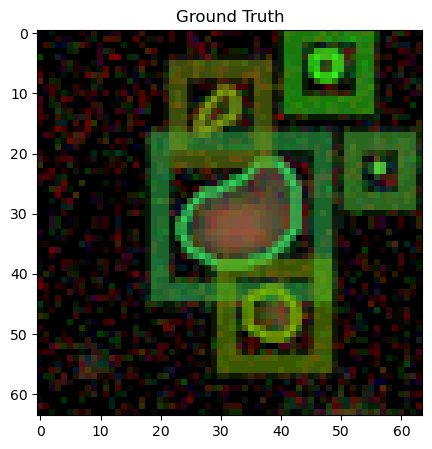

In [52]:
import matplotlib.pyplot as plt
from deepdisc.astrodet.visualizer import Visualizer
from deepdisc.astrodet.visualizer import ColorMode

from astropy.visualization import make_lupton_rgb

plt.figure(figsize=(5,5))

mCoadd_cutout = coadd_cutout.image.array

img = make_lupton_rgb(mCoadd_cutout[3],mCoadd_cutout[2],mCoadd_cutout[1],stretch=15,Q=10)


print("total instances:", len(ddict["annotations"]))
v0 = Visualizer(
    img,
    metadata=astrotest_metadata,
    scale=1,
    instance_mode=ColorMode.SEGMENTATION,  # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
groundTruth = v0.draw_dataset_dict(ddict, lf=False, alpha=0.1)

ax1 = plt.subplot(1, 1, 1)
ax1.imshow(groundTruth.get_image())
#ax1.axis("off")
plt.title('Ground Truth')

